# DESAFIO IC — VOXAR LABS 2025/2026
## Classificação de Superfícies de Vias por Imagem

---
**Autor:** Arthur Gabriel Silva da Luz  
**Data:** 30/04/2026

---

## Índice

1. [Identificação da Abordagem](#1)
2. [Configurações globais do colab](#2)
3. [EDA - Análise Explorativa de Dados](#3)
4. [Pré-processamento e transformações de dados](#4)

In [ ]:
!pip install opencv-python
!pip install grad-cam

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import cv2 # Para analisar o brilho/contraste das imagens q nem escrito no pdf da Voxar
from PIL import Image
import random

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split, Subset
from torchvision.models import resnet50, ResNet50_Weights, resnet18, ResNet18_Weights
from torchvision.datasets import ImageFolder
from torchvision.utils import make_grid

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

from tqdm import tqdm # Barra de progresso para verificar o treinamento

from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve, precision_recall_curve

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 77.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=06799ba3615f16c700f06671b80371acf701d2d31f1df031563bc0994972ebd4
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


<a id='1'></a>
## 1. Identificação da Abordagem

### Natureza do Problema

Classificação supervisionada de imagens em **3 classes de superfície**:

- **Classe 1**: Asphalt        | Asfalto, superfície uniforme
- **Classe 2**: Belgian_blocks | Paralelepípedos ou blocos de granito
- **Classe 3**: Offroad        | Superfície não pavimentada(terra, cascalho, areia...)

### Desafios Antecipados

- **Desbalanceamento severo**: o pdf enviado explica que o dataset está altamente desbalanceado, logo os modelos terão uma tendência a ignorar classes minoritárias.

- **Variações de captura**: iluminação variável (chuva, noite, sol direto), múltiplos dispositivos de captura e ângulos de câmera.

- **Ambiguidade visual**: asphalt molhado pode assemelhar-se a belgian_blocks; offroad com lama pode parecer asphalt escuro.

### Abordagem Escolhida: Transfer Learning com ResNet50

**Justificativa**: a rede ResNet50 pré-treinada no ImageNet possui representações de textura, bordas e padrões, o que eu espero que consiga diferenciar as 3 classes. A ideia é que o fine-tuning parcial seja superior ao treino do zero quando o dataset é pequeno e desbalanceado. O uso do ResNet50 também está com base no seguinte artigo <a href='https://arxiv.org/abs/2010.11929'>An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale</a> que indica que esse modelo dá bons resultados em datasets com poucas imagens.

**Estratégia**:
1. *Baseline puro*: Uso da ResNet sem correção alguma.
2. *Pesos na Loss Function*: Mitigação do viés estatístico causado pela diferença na quantidade de imagens entre as classes.
3. *Data Augmentation + Resize via CenterCrop*: descongela camadas finais com lr reduzido para ajuste fino ao domínio.

### Métricas principais e ferramentas de análise:
* **F1-Score por Classe**
* **Matriz de confusão**
* **Recall**

### Bibliotecas Utilizadas
- **PyTorch**: modelo, treinamento, DataLoader
- **scikit-learn**: métricas (balanced accuracy, F1, report, confusion matrix)
- **matplotlib / seaborn**: visualizações
- **numpy / pandas**: manipulação de dados

<a id='2'></a>
# 2. Configurações globais do colab

Foca em centralizar as informações globais do colab para tornar mais fácil a reprodutibilidade.

In [ ]:
config = {
    'data_dir': '/content/drive/MyDrive/datasets/dataset_voxar', # Vou deixar o path assim e na hora de utilizar direciono se é para treino, teste e uma das categorias.
    'batch_size': 32,# PARA O IMAGENET
    'num_workers': 2,
    'num_epochs': 20,
    'learning_rate': 0.0001,
    'device': 'cuda' if torch.cuda.is_available() else "cpu",
    'model_save.pth' : 'modelo_colab.pth' # Mudar pra cada modelo que eu treine
    'classes': ["asphalt", "belgian_blocks", "offroad"]
}

In [ ]:
def all_seeds(seed):
  random.seed(seed)
  np.random.seed(seed)
  torch.manual_seed(seed)
  torch.cuda.manual_seed_all(seed)
  torch.backends.cudnn.deterministic = True
  torch.backends.cudnn.benchmark = False

all_seeds(42)

In [ ]:
device = torch.device(config['device'])
device

device(type='cuda')

<a id='3'></a>

<h1>3. EDA - Análise Explorativa de Dados 📊</h1>

Nessa seção, será visualizada o número de imagens por classe no split de treino e outros fatores.

Antes de qualquer processo de tratamento e treinamento, é essencial ter noção do quão desbalanceado é o dataset. A ideia é que após a análise explorativa dos dados seja possível responder algumas perguntas como:

1. **Qual o grau de desbalanceamento?** - A resposta dessa pergunta influenciará na distribuição dos pesos na loss function.

2. **Qual a variação de resolução?** - A resposta dessa pergunta me orientará quanto a estratégia de redimensionamento das imagens.

3. **Como é a distribuição do brilho nas imagens?** - Indica se augmentation faz sentido.


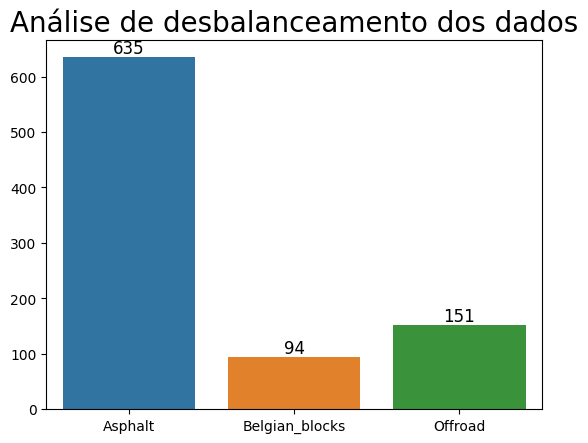

In [ ]:
quantidade_asphalt = len(os.listdir(config['data_dir']+'/train/asphalt'))
quantidade_belgian = len(os.listdir(config['data_dir']+'/train/belgian_blocks'))
quantidade_offroad = len(os.listdir(config['data_dir']+'/train/offroad'))

train_size = pd.DataFrame.from_dict({
    'Asphalt': [quantidade_asphalt],
    'Belgian_blocks': [quantidade_belgian],
    'Offroad': [quantidade_offroad]
})

grafico_em_barras = sns.barplot(data=train_size)
grafico_em_barras.set_title('Análise de desbalanceamento dos dados', fontsize=20)

for barra in grafico_em_barras.patches:
  altura_barra = barra.get_height()

  grafico_em_barras.annotate(f'{int(altura_barra)}',
                            (barra.get_x()+ barra.get_width()/2, altura_barra),
                            ha='center',
                            va='bottom',
                            fontsize=12,)

plt.show()

`Leitura Rápida`

Existem 635 imagens da classe Asphalt, 94 imagens com a classe belgian_blocks e 151 imagens com a classe offroad. Logo, `asphalt` coresponde a 72,15% das amostras de treino, enquanto `belgian_blocks` corresponde a 10,68%. A consequência direta é que a acurácia é uma métrica **TOTALMENTE ENGANOSA** nesse caso. Uma vez que um classificador que somente preveja a classe `asphalt` acertará 72% das vezes, sem aprender nada sobre as imagens. Portanto, a métrica f1-score e f1-macro serão bastante importante.

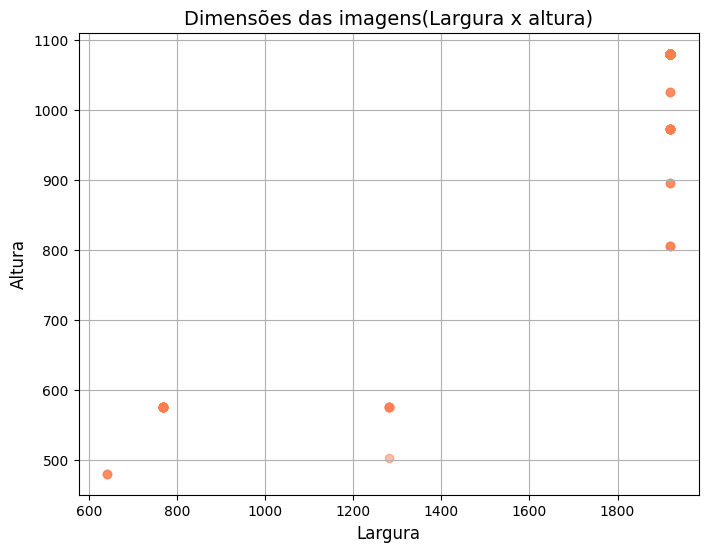


-------------------------------------------------------
 Informações das dimensões das imagens:

Largura mínima: 640 px
Largura máxima: 1920 px

Altura mínima: 480px
Altura máxima: 1080px

Média de largura: 1769 px
Média de altura: 988 px
-------------------------------------------------------


In [ ]:
"""
Essa função tem como objetivo analisar as dimensões das imagens.
As imagens costumam ter diferentes tipos de resolução, podendo ir geralmente de 1920x1080
a 16x16. Se as imagens forem muito grandes, dimensioná-las para 224x224 através de um ReSize,
as imagens podem ficar um pouco distorcidas, impactando negativamente na performance do modelo.
"""
def analyze_images(data_dir, quantidade_amostras=200):
  classes = ['asphalt', 'belgian_blocks', 'offroad']
  path = data_dir+'/train'

  all_images = []

  for classe in classes:
    path_class = path + '/' + classe
    name_archives = os.listdir(path_class) # Listar todos os arqiuvos

    for name_arc in name_archives:
      all_images.append(path_class + '/' + name_arc)

  random.shuffle(all_images) # Embaralhar as imagens de acordo com a seed lá do início
  samples_img = all_images[:quantidade_amostras] # Pega as 100 primeiras imagens dentro da ordem aleatória do random.shuffle

  widths = []  # largura
  heights = [] # altura

  for name_img in samples_img:
    img = Image.open(name_img)
    width_img, height_img = img.size

    widths.append(width_img) # Descobrir os pixels/dimensão da imagem, planejo fazer um resize, caso necessário.
    heights.append(height_img)

  # Criação do gráfico a partir dos dados
  plt.figure(figsize=(8,6))
  plt.scatter(widths, heights, color='coral', alpha=0.5) # alpha=0.5 é pra deixar meio transparente meio opaco
  plt.title('Dimensões das imagens(Largura x altura)', fontsize=14)
  plt.xlabel('Largura', fontsize=12)
  plt.ylabel('Altura', fontsize=12)
  plt.grid(True)
  plt.show()

  print()
  print('-'*55)
  print(' Informações das dimensões das imagens:')
  print()
  print(f'Largura mínima: {min(widths)} px')
  print(f'Largura máxima: {max(widths)} px')

  print(f'\nAltura mínima: {min(heights)}px')
  print(f'Altura máxima: {max(heights)}px')

  print(f'\nMédia de largura: {np.mean(widths):.0f} px')
  print(f'Média de altura: {np.mean(heights):.0f} px')
  print('-' * 55)


analyze_images(config['data_dir'])



`Leitura Rápida`

A maioria das imagens está próxima de 1920x1080. Redimensionar para 224x224 indicaria diminuir a escala da imagem em 8,5x, o que pode deixar muito difícil para o modelo detectar os paralelepípedos nos belgian_blocks e erroneamente indicando Asphalt como resposta. Para tanto, será necessário usar o ReSize junto ao CenterCrop durante o Data augmentation.

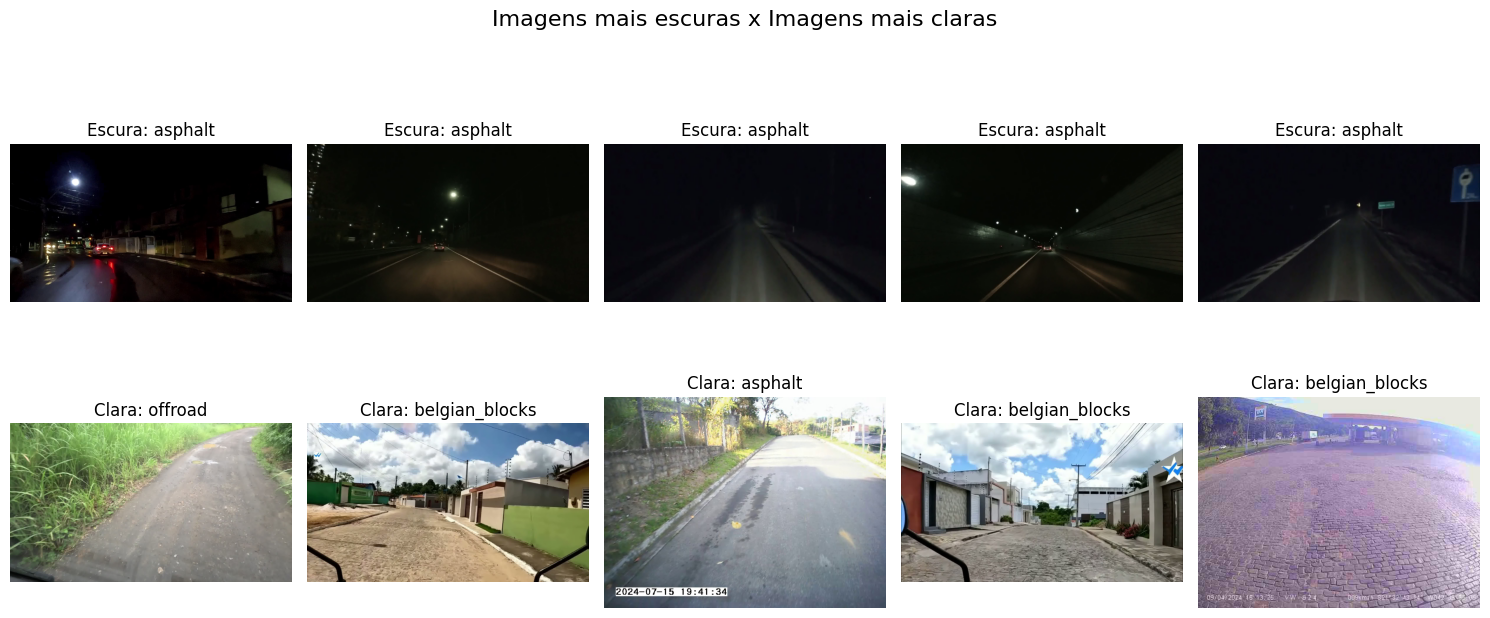

In [ ]:
def extreme_analysis_images(data_dir, quantidade_amostras=5):
  # ESsa primeira parte só dei ctrl c ctrl v da função anterior
  classes = ['asphalt', 'belgian_blocks', 'offroad']
  path = data_dir+'/train'

  all_images = []

  for classe in classes:
    path_class = path + '/' + classe
    name_archives = os.listdir(path_class) # Listar todos os arqiuvos

    for name_arc in name_archives:
      all_images.append(path_class + '/' + name_arc)

  random.shuffle(all_images) # Embaralhar as imagens de acordo com a seed lá do início
  samples_to_analyze = all_images[:200] # Pega as 100 primeiras imagens dentro da ordem aleatória do random.shuffle

  #A partir daqui o código diferencia da função passada.

  # Calcular o brilho médio da imagem e colocá-la numa ordem da mais escura até a mais clara
  brightness_list = []

  for name_img in samples_to_analyze:
    img = Image.open(name_img)

    gray_image = img.convert('L') # Converter imagem em preto e branco numa escala cinzenta
    array_px = np.array(gray_image)

    medium_brightness = np.mean(array_px)

    brightness_list.append((name_img, medium_brightness)) # armazena caminho e brilho juntos

  brightness_list.sort(key=lambda x: x[1]) # dar sort de acordo com o valor de brilho médio, imagens mais escuras -> imagens mais claras

  dark_imgs = brightness_list[:quantidade_amostras]
  light_imgs = brightness_list[-quantidade_amostras:]

  # Configuração do gráfico e de plotagem

  fig, eixos = plt.subplots(2, quantidade_amostras, figsize=(15,7)) # figuras e eixos
  fig.suptitle('Imagens mais escuras x Imagens mais claras', fontsize=16)

  for indice in range(quantidade_amostras):
      # Desenhando as imagens escuras na primeira linha (índice 0)
      caminho_escura = dark_imgs[indice][0]
      imagem_escura = Image.open(caminho_escura)
      eixos[0, indice].imshow(imagem_escura)
      nome_da_classe_escura = caminho_escura.split('/')[-2] # Pega o nome da pasta
      eixos[0, indice].set_title(f"Escura: {nome_da_classe_escura}")
      eixos[0, indice].axis('off') # Esconde os eixos de números

      # Desenhando as imagens claras na segunda linha (índice 1)
      caminho_clara = light_imgs[indice][0]
      imagem_clara = Image.open(caminho_clara)
      eixos[1, indice].imshow(imagem_clara)
      nome_da_classe_clara = caminho_clara.split('/')[-2]
      eixos[1, indice].set_title(f"Clara: {nome_da_classe_clara}")
      eixos[1, indice].axis('off')

  plt.tight_layout()
  plt.show()

extreme_analysis_images(config['data_dir'])

`Leitura Rápida`

As imagens mais escuras incluem cenas praticamente totalmente escuras, e em todos os casos demonstrados são da classe `asphalt`, o que indica que não é possível confiar em pistas de brilho para classificar(posteriormente as imagens serão analisadas com Grad-Cam) e o modelo pode aprender com essa característica de maneira errônea. As imagens mais claras, por outro lado, mostram textura de solo nítidas o bastante para ser facilmente classificada. O maior desafio vai ser fazer com que o modelo classifique corretamente nas imagens de baixa iluminação.

<a id='4'></a>
# 4. Pré-processamento e transformações de dados

In [ ]:
# Normalização da ImageNet usada nos pipelines de forma tradicional
normal_mean = [0.485, 0.456, 0.406]
standard_mean = [0.229, 0.224, 0.225]

# Para o baseline(experimento 1):

baseline_transf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(normal_mean, standard_mean),
])

# Para o experimento 2: ReSize+CenterCrop para análise da imagem
# mais CollorJitter e rotações para testar diferentes iluminações e ângulos de imagem:
treino_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=normal_mean, std=standard_mean)
])

#Pipeline de avaliação determinístico(sem aleatoriedade)
val_test_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=normal_mean, std=standard_mean)
])

<a id='5'></a>
# 5. Criação da Baseline - Resnet50

In [ ]:
# Carregamento dos dados:

root_train = config['data_dir']+'/train'
root_test = config['data_dir']+'/test'

baseline_train_dataset = ImageFolder(root=root_train, transform=baseline_transf)
baseline_test_dataset =  ImageFolder(root=root_test, transform=baseline_transf)

baseline_train_dataloader = DataLoader(baseline_train_dataset,
                                 batch_size= config['batch_size'],
                                 shuffle=True,)

baseline_test_dataloader = DataLoader(baseline_test_dataset,
                                      batch_size=config['batch_size'],
                                      shuffle=False)

print(f'Classes: {baseline_train_dataset.classes}')
print(f'Imagens para treinamento: {len(baseline_train_dataset)}')
print(f'Imagens para teste:       {len(baseline_test_dataset)}')


Classes: ['asphalt', 'belgian_blocks', 'offroad']
Imagens para treinamento: 880
Imagens para teste:       300


In [ ]:
baseline = resnet18(weights=ResNet18_Weights.DEFAULT)

baseline_features = baseline.fc.in_features

baseline.fc = nn.Linear(baseline_features, len(baseline_train_dataset.classes))

baseline_model = baseline.to(device)

#Cálculo da loss function e o otimizador

loss_baseline = nn.CrossEntropyLoss()

optimizer_baseline = optim.Adam(baseline_model.parameters(), lr=config['learning_rate'])



Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 179MB/s]


# Função de treinamento:

In [ ]:
def model_train(model, train_loader, test_loader, loss_function, optimizer, epochs, device):
  print('Início do treino\n')

  for epoch in range(epochs):
    model.train()

    train_loss = 0.0
    right_train = 0
    total_train = 0

    for images, labels in tqdm(train_loader):

      images = images.to(device)
      labels = labels.to(device)

      # Reiniciar os gradientes do loop de antes
      optimizer.zero_grad()

      # Prevejo com base na imagem (Forward pass)
      prevision = model(images)

      # Calculo o erro
      loss = loss_function(prevision, labels)

      # Backpropagation para ajuste dosp esos
      loss.backward()

      # Atualização dos pesos
      optimizer.step()

      #Guardar as estatísticas
      train_loss += loss.item() * images.size(0)
      n, predicted = torch.max(prevision, 1) # só tenho interesse no predicted, esse "n" poderia facilmente ser qualquer outra variável, pq nn vou usá-lo
      right_train += torch.sum(predicted==labels).item()
      total_train += labels.size(0)

    accuracy_train = right_train / total_train
    avg_train_loss = train_loss / len(train_loader.dataset)

    # Validação e teste

    model.eval()
    test_loss = 0.0
    right_test = 0
    total_test = 0

    with torch.no_grad():
      for images, labels in tqdm(test_loader):
        images = images.to(device)
        labels = labels.to(device)

        prevision = model(images)
        error = loss_function(prevision, labels)

        test_loss += error.item() * images.size(0)
        ns, predicted_class = torch.max(prevision, 1)
        right_test += torch.sum(predicted_class==labels).item()
        total_test += labels.size(0)

    accuracy_test = right_test / total_test
    avg_test_loss = test_loss / len(test_loader.dataset)


    print(f'Época: {epoch+1}/{epochs}\n'
          f'Erro treino: {avg_train_loss:.4f} // Acurácia do treino: {accuracy_train:.4f}\n' # Coloquei a acurácia como métrica só para mostrar o quanto ela é uma métrica enganosa.
          f'Erro teste: {avg_test_loss:.4f}   // Acurácia do teste: {accuracy_test:.4f}\n')


In [ ]:
# Treino da baseline


model_train(baseline_model, baseline_train_dataloader, baseline_test_dataloader, loss_baseline, optimizer_baseline, epochs=10, device=config['device'])

Início do treino



100%|██████████| 10/10 [01:56<00:00, 11.65s/it]


Época: 1/10
Erro treino: 0.3131 // Acurácia do treino: 0.8761
Erro teste: 0.3397   // Acurácia do teste: 0.9067



100%|██████████| 10/10 [00:05<00:00,  1.70it/s]


Época: 2/10
Erro treino: 0.0272 // Acurácia do treino: 0.9932
Erro teste: 0.2106   // Acurácia do teste: 0.9333



...

Época: 8/10
Erro treino: 0.0088 // Acurácia do treino: 0.9966
Erro teste: 0.2792   // Acurácia do teste: 0.9233



100%|██████████| 10/10 [00:06<00:00,  1.65it/s]


Época: 9/10
Erro treino: 0.0124 // Acurácia do treino: 0.9966
Erro teste: 0.4083   // Acurácia do teste: 0.8800



100%|██████████| 10/10 [00:06<00:00,  1.56it/s]

Época: 10/10
Erro treino: 0.0103 // Acurácia do treino: 0.9977
Erro teste: 0.2724   // Acurácia do teste: 0.8967



In [ ]:
# Criação da matriz_de_confusão

def confusion_matrix_avaliation(model, test_loader, classes, device):
  all_labels = []
  all_pred = []

  model.eval()

  with torch.no_grad():
    for img, label in tqdm(test_loader):
      img = img.to(device)
      label = label.to(device)

      prevision = model(img)
      nt, predicted = torch.max(prevision, 1)

      all_labels.extend(label.cpu().numpy())
      all_pred.extend(predicted.cpu().numpy())

  matrix_baseline = confusion_matrix(all_labels, all_pred)

  plt.figure(figsize=(8,6))

  sns.heatmap(matrix_baseline, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)

  plt.title('Matriz de confusão (Baseline)',fontsize=16)
  plt.xlabel('Classe prevista', fontsize=12)
  plt.ylabel('Classe real', fontsize=12)
  plt.show()

  print('Relatório com o f1-score:')
  print(classification_report(all_labels, all_pred,target_names=classes))

100%|██████████| 10/10 [00:06<00:00,  1.46it/s]


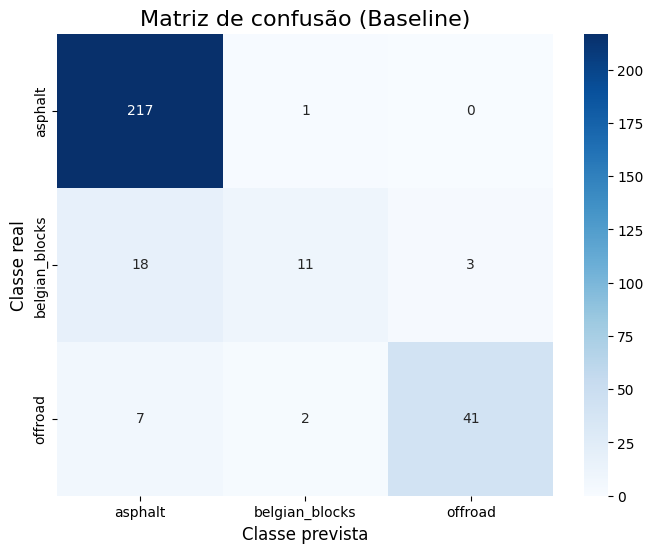

Relatório com o f1-score:
                precision    recall  f1-score   support

       asphalt       0.90      1.00      0.94       218
belgian_blocks       0.79      0.34      0.48        32
       offroad       0.93      0.82      0.87        50

      accuracy                           0.90       300
     macro avg       0.87      0.72      0.76       300
  weighted avg       0.89      0.90      0.88       300



In [ ]:
confusion_matrix_avaliation(baseline_model, baseline_test_dataloader, baseline_train_dataset.classes, device)

# Análise crítica do `baseline` pela matriz de confusão:

O modelo desenvolveu um viés para a classe majoritária (asphalt). É possível perceber facilmente quando olhamos para a matriz de confusão, na classe belgian_blocks e das 32 imagens, somente 11 ele classificou corretamente como belgian_blocks, enquanto 18 dessas imagens foram classificadas como asphalt. Portanto, o modelo aprendeu que "chutar" Asphalt era mais vantajoso para diminuir o erro geral, do que aprender as características visuais dos belgian_blocks.

<h2>Aplicação de pesos na função de perda:</h2>

O modelo da forma que está atualmente penaliza todos os erros com um mesmo **peso**. Como existem muito mais imagens de asfalto, errar um paralelepípedo "custa pouco" para a rede durante o treino. A hipótese que será testada logo em seguida é: atribuir pesos maiores para erros nas classes minoritárias diretamente na função de custo (CrossEntropyLoss) e forçar o modelo a prestar mais atenção nos bridge_blocks.

In [ ]:
# Aplicação dos pesos

weight_asphalt = 1.0 / quantidade_asphalt
weight_belgian = 1.0 / quantidade_belgian
weight_offroad = 1.0 / quantidade_offroad

# bse = baseline // Vou diminuir a quantidade de letras para ficar mais fácil e rápido de digitar.

# Configuração do teste de baseline 2.
global_weights = torch.tensor([weight_asphalt, weight_belgian, weight_offroad], dtype=torch.float).to(config['device']) # Atualização de pesos para usar para sempre.

loss_balanced_bse2 = nn.CrossEntropyLoss(weight=global_weights)

bse2_exp = resnet18(weights=ResNet18_Weights.DEFAULT)
bse2_features = bse2_exp.fc.in_features
bse2_exp.fc = nn.Linear(bse2_features, len(baseline_train_dataset.classes))
bse2_model = bse2_exp.to(device)

loss_bse2 = nn.CrossEntropyLoss(weight=global_weights)

optimizer_bse2 = optim.Adam(bse2_model.parameters(), lr= config['learning_rate'])

# Treino do baseline2

model_train(bse2_model, baseline_train_dataloader, baseline_test_dataloader, loss_bse2, optimizer_bse2, epochs=10, device=config['device'])


Início do treino



100%|██████████| 10/10 [00:06<00:00,  1.45it/s]


Época: 1/10
Erro treino: 0.3164 // Acurácia do treino: 0.8148
Erro teste: 0.3177   // Acurácia do teste: 0.8967



100%|██████████| 10/10 [00:07<00:00,  1.35it/s]


Época: 2/10
Erro treino: 0.0343 // Acurácia do treino: 0.9920
Erro teste: 0.2166   // Acurácia do teste: 0.9267



...

Época: 8/10
Erro treino: 0.0070 // Acurácia do treino: 0.9989
Erro teste: 0.2275   // Acurácia do teste: 0.9367



100%|██████████| 10/10 [00:07<00:00,  1.34it/s]


Época: 9/10
Erro treino: 0.0047 // Acurácia do treino: 0.9989
Erro teste: 0.2448   // Acurácia do teste: 0.9267



100%|██████████| 10/10 [00:07<00:00,  1.35it/s]

Época: 10/10
Erro treino: 0.0032 // Acurácia do treino: 1.0000
Erro teste: 0.2829   // Acurácia do teste: 0.9167




 Avaliação do Experimento com pesos diferentes para o baseline2


100%|██████████| 10/10 [00:06<00:00,  1.63it/s]


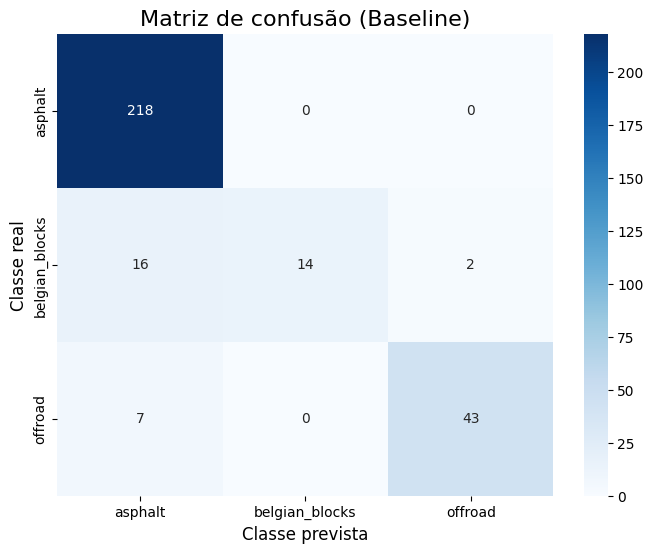

Relatório com o f1-score:
                precision    recall  f1-score   support

       asphalt       0.90      1.00      0.95       218
belgian_blocks       1.00      0.44      0.61        32
       offroad       0.96      0.86      0.91        50

      accuracy                           0.92       300
     macro avg       0.95      0.77      0.82       300
  weighted avg       0.92      0.92      0.91       300



In [ ]:
# Avaliação da matriz de confusão com o baseline:

print("\n Avaliação do Experimento com pesos diferentes para o baseline2")
confusion_matrix_avaliation(
    model=bse2_model,
    test_loader=baseline_test_dataloader,
    classes=baseline_train_dataset.classes,
    device=config['device']
)

<h1>Análise crítica do `baseline2`pela matriz de confusão:</h1>

A aplicação de pesos na função de perda apresentou bons resultados em mitigar uma parte do viés estatístico. O F1-Score da classe belgian_blocks apresentou uma boa melhora, saltando de 0.48 para 0.68, e o recall aumentou de 0.34 para 0.53, além da diminuição de falsos positivos para asfalto e a melhora no recall e f1-score na classe offroad.

Entretanto, o modelo ainda possui uma dificuldade intrínseca em separar as características visuais dos blocos belgas, confundindo-os frequentemente com asfalto ou terra.

<h2>Nova experimentação (Baseline 3): Agora vou focar em melhorar a robustez visual com data augmentation</h2>

**Motivo**: O Resize utilizado em todos os testes anteriores foi para 224x224, porém como visto na análise explorativa de dados, a grande maioria dos arquivos de imagem estão próximos de 1920x1080, portanto ao redimensionar essas imagens, elas são distorcidas, e possivelmente as linhas dos belgian_blocks(paralelepípedos) não ficam bem reproduzidas na imagem, possivelmente causando problema na avaliação e marcando como asfalto, além de claro, as condições de iluminação extremas para o bem ou para o mal.

In [ ]:
# Mudando a forma que os dados das imagens vão ser treinados:
treino_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=normal_mean, std=standard_mean)
])

val_test_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=normal_mean, std=standard_mean)
])

# O nome do 3° baseline será "bline3"

In [ ]:

bline3_train = ImageFolder(root=root_train, transform=treino_transforms)
bline3_test =  ImageFolder(root=root_test, transform=treino_transforms)

bline3_train_loader = DataLoader(bline3_train,
                                 batch_size= config['batch_size'],
                                 shuffle=True,)

bline3_test_loader = DataLoader(bline3_test,
                                batch_size=config['batch_size'],
                                shuffle=False)

loss_balanced_bline3 = nn.CrossEntropyLoss(weight=global_weights)

# Criação do modelo de baseline3
bline3_exp = resnet18(weights=ResNet18_Weights.DEFAULT)
bline3_features = bline3_exp.fc.in_features
bline3_exp.fc = nn.Linear(bline3_features, len(baseline_train_dataset.classes))
bline3_model = bline3_exp.to(device)

loss_bline3 = nn.CrossEntropyLoss(weight=global_weights)

optimizer_bline3 = optim.Adam(bline3_model.parameters(), lr= config['learning_rate'])

# Treino do baseline3

model_train(bline3_model, bline3_train_loader, bline3_test_loader, loss_bline3, optimizer_bline3, epochs=10, device=config['device'])

Início do treino



100%|██████████| 10/10 [00:07<00:00,  1.39it/s]


Época: 1/10
Erro treino: 0.4203 // Acurácia do treino: 0.7602
Erro teste: 0.4228   // Acurácia do teste: 0.8100



100%|██████████| 10/10 [00:09<00:00,  1.10it/s]


Época: 2/10
Erro treino: 0.0942 // Acurácia do treino: 0.9739
Erro teste: 0.4906   // Acurácia do teste: 0.8167



...

Época: 8/10
Erro treino: 0.0133 // Acurácia do treino: 0.9977
Erro teste: 0.2657   // Acurácia do teste: 0.8933



100%|██████████| 10/10 [00:08<00:00,  1.15it/s]


Época: 9/10
Erro treino: 0.0046 // Acurácia do treino: 1.0000
Erro teste: 0.3071   // Acurácia do teste: 0.9033



100%|██████████| 10/10 [00:07<00:00,  1.31it/s]

Época: 10/10
Erro treino: 0.0042 // Acurácia do treino: 0.9989
Erro teste: 0.3016   // Acurácia do teste: 0.9067



100%|██████████| 10/10 [00:08<00:00,  1.14it/s]


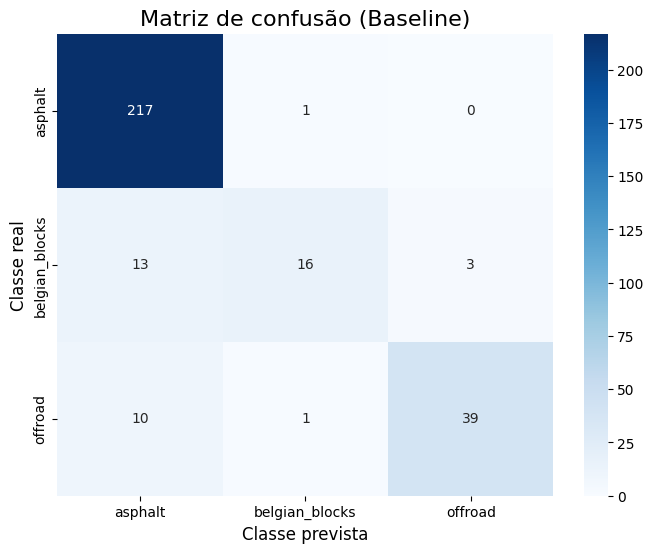

Relatório com o f1-score:
                precision    recall  f1-score   support

       asphalt       0.90      1.00      0.95       218
belgian_blocks       0.89      0.50      0.64        32
       offroad       0.93      0.78      0.85        50

      accuracy                           0.91       300
     macro avg       0.91      0.76      0.81       300
  weighted avg       0.91      0.91      0.90       300



In [ ]:
# Avaliação da matriz de confusão
confusion_matrix_avaliation(
    model=bline3_model,
    test_loader=bline3_test_loader,
    classes=baseline_train_dataset.classes,
    device=config['device']
)

# Avaliação crítica do grad-cam nos experimentos 2 e 3:

A aplicação de data augmentation e centercrop piorou o desempenho geral do modelo

In [ ]:
# Visualização com grad-cam


def visualization_grad_cam(model, dataset_test, device, quantity=5):
  layer_target = [model.layer4[-1]]
  heat_cam = GradCAM(model=model, target_layers=layer_target)

  fig, eixos = plt.subplots(2, quantity, figsize=(16,8))
  fig.suptitle('Grad-CAM: Análise de para onde o modelo olha', fontsize=16)

  idx_random = np.random.choice(len(dataset_test), quantity, replace=False)

  for column, index in enumerate(idx_random):
    img_tensor, real_label = dataset_test[index]

    batch_tensor = img_tensor.unsqueeze(0).to(device)

    target = [ClassifierOutputTarget(real_label)]
    grad_cam_img = heat_cam(input_tensor=batch_tensor, targets=target)

    grad_cam_2d = grad_cam_img[0, :]

    normal_mean = np.array([0.485, 0.456, 0.406])
    standard_mean = np.array([0.229, 0.224, 0.225])

    origin_image = img_tensor.cpu().numpy().transpose(1, 2, 0)
    origin_image = standard_mean * origin_image + normal_mean
    origin_image = np.clip(origin_image, 0, 1) # pixels entre 0 e 1

    img_with_map = show_cam_on_image(origin_image, grad_cam_2d, use_rgb=True)

    real_label_name = dataset_test.classes[real_label]

    model.eval()

    with torch.no_grad():
      prevision = model(batch_tensor)
      ni, predicted_class = torch.max(prevision, 1)
      predicted_class_name = dataset_test.classes[predicted_class[0].item()]

    eixos[0, column].imshow(origin_image)
    eixos[0, column].set_title(f"Real: {real_label_name}")
    eixos[0, column].axis('off')

    # Desenhando a imagem com o mapa de calor na linha de baixo
    eixos[1, column].imshow(img_with_map)
    # Se errou, coloca o título em vermelho para destacar
    cor_titulo = 'green' if real_label == predicted_class[0].item() else 'red'
    eixos[1, column].set_title(f"Previsão: {predicted_class_name}", color=cor_titulo)
    eixos[1, column].axis('off')

  plt.tight_layout()
  plt.show()


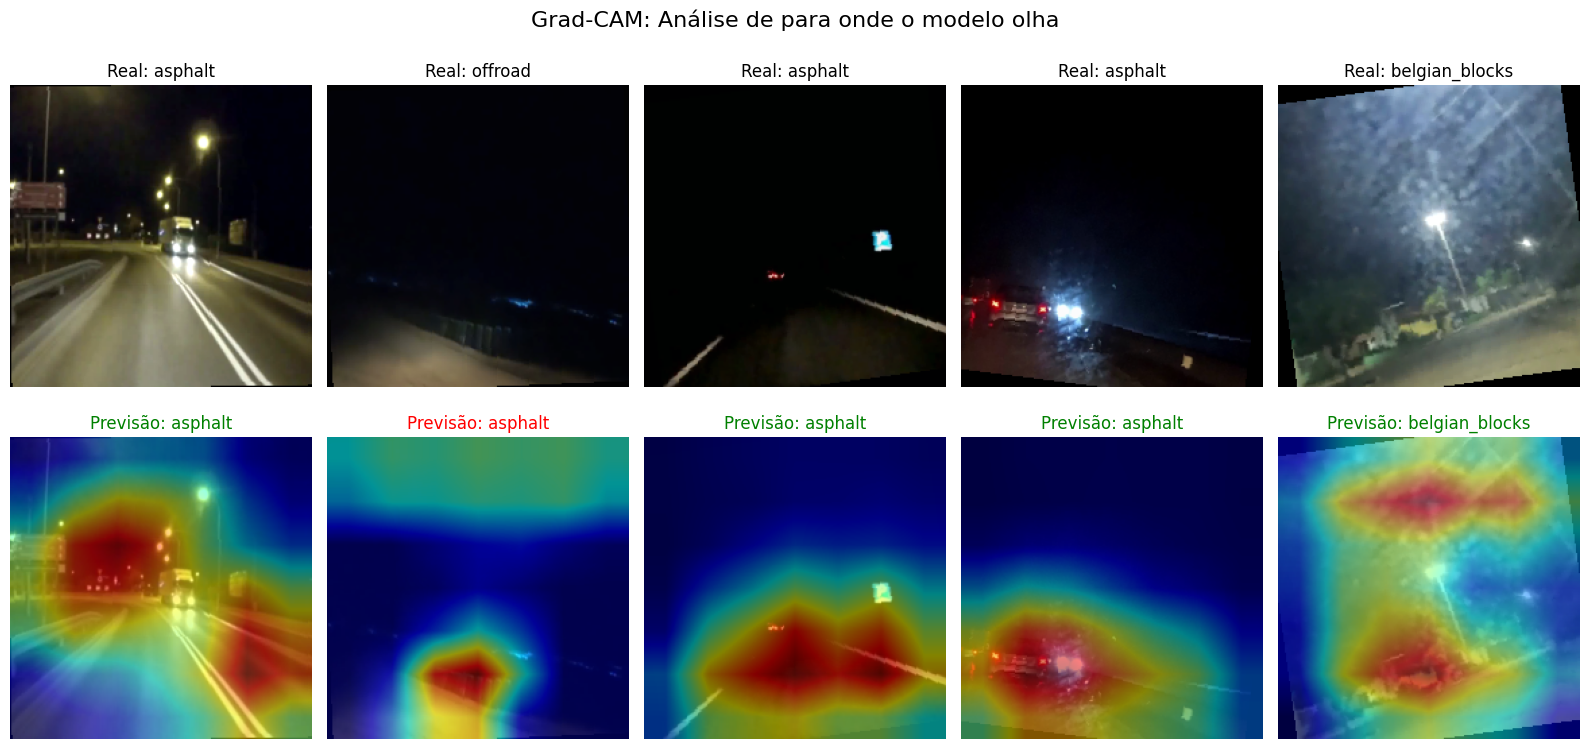

In [ ]:
# Visualização do grad-cam para o experimento2
visualization_grad_cam(
    model=bline3_model,
    dataset_test=bline3_test,
    device=config['device']
)

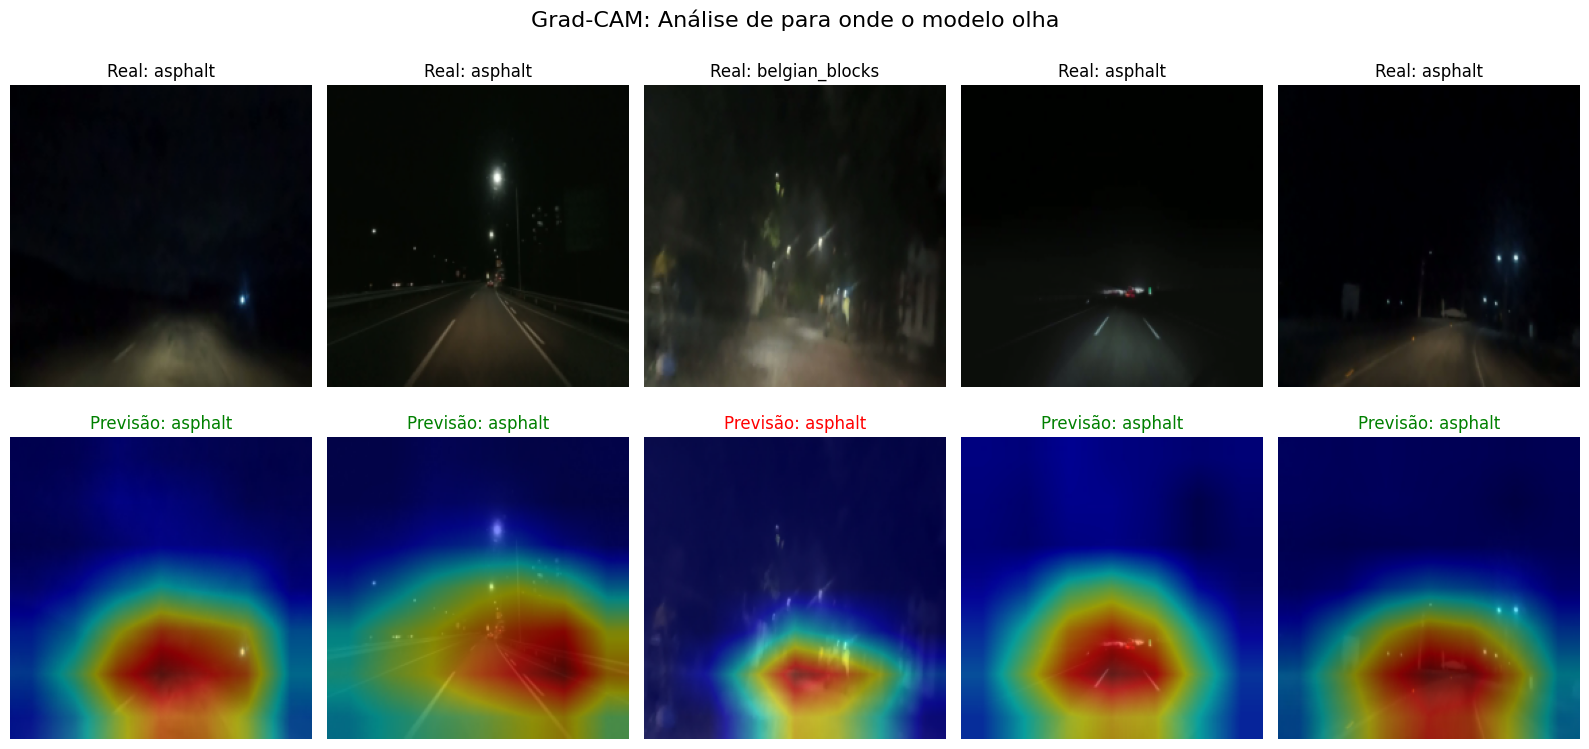

In [ ]:
visualization_grad_cam(
    model=bse2_model,
    dataset_test=baseline_test_dataset,
    device=config['device']
)